**Regression in Supernova I**

Fit with linear and then polinomial, looking for the best model regression.

In [78]:
import matplotlib.pyplot as plt
import numpy as np

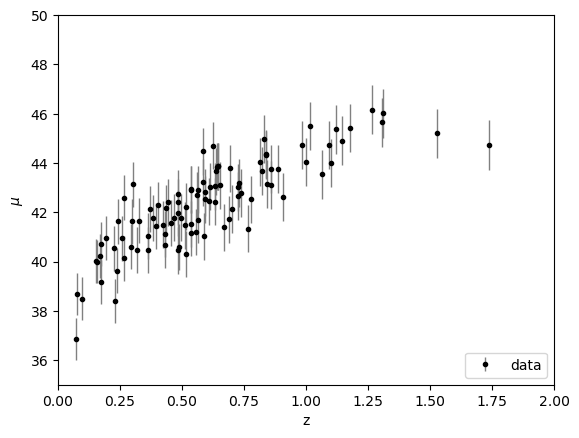

In [79]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) 

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [ ]:
# Cross validation routine

# Zanin suggested to pass also eteroschedastic error, but I don't have control over astroML datasets, so I will just ignore it for now.
# I will use the same error for all points, which is not ideal but should be sufficient for this demonstration.

def cross_validation(x, y, model):
    validate_size = 0.25
    X = np.asarray(x)
    Y = np.asarray(y)

    chunk = int(validate_size * len(X))
    n_folds = int(1 / validate_size)
    training_error = 0
    crossval_error = 0

    for k in range(n_folds):
        start = k * chunk
        end = (k + 1) * chunk if k < n_folds - 1 else len(X)

        X_validate = X[start:end]
        Y_validate = Y[start:end]

        X_train = np.concatenate((X[:start], X[end:]), axis=0)
        Y_train = np.concatenate((Y[:start], Y[end:]), axis=0)

        model.fit(X_train[:, np.newaxis], Y_train)
        training_error += np.sum((model.predict(X_train[:, np.newaxis]) - Y_train) ** 2)/len(X_train)
        crossval_error += np.sum((model.predict(X_validate[:, np.newaxis]) - Y_validate) ** 2)/len(X_validate)

    training_error /= n_folds
    crossval_error /= n_folds

    return np.sqrt(training_error), np.sqrt(crossval_error)


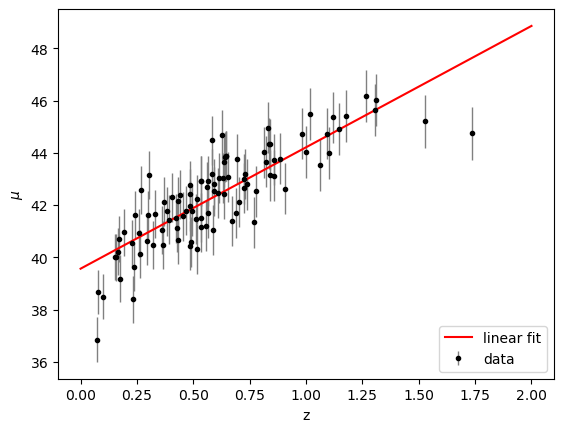

b = 39.56505554722625, a = 4.6471184795912945


In [81]:
# Linear regression

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(z_sample[:, np.newaxis], mu_sample)
z_fit = np.linspace(0, 2, 100)
mu_fit = model.predict(z_fit[:, np.newaxis])

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(z_fit, mu_fit, '-r', label='linear fit')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.show()

theta0 = model.intercept_
theta1 = model.coef_[0]

print("b = {}, a = {}".format(theta0, theta1))

In [82]:
tr_err, cv_err = cross_validation(z_sample, mu_sample, model)
print ("Cross validation score: {}".format(cv_err))
print ("Training error: {}".format(tr_err))

Cross validation score: 1.0403147976240856
Training error: 0.9787899385208895


Degree: 1, Training error: 0.9788, Cross validation error: 1.0403
Degree: 2, Training error: 0.9007, Cross validation error: 0.9377
Degree: 3, Training error: 0.8965, Cross validation error: 1.1903
Degree: 4, Training error: 0.8663, Cross validation error: 1.0447
Degree: 5, Training error: 0.8577, Cross validation error: 3.9798
Degree: 6, Training error: 0.8515, Cross validation error: 12.4319
Degree: 7, Training error: 0.8425, Cross validation error: 0.9405
Degree: 8, Training error: 0.8415, Cross validation error: 12.7672


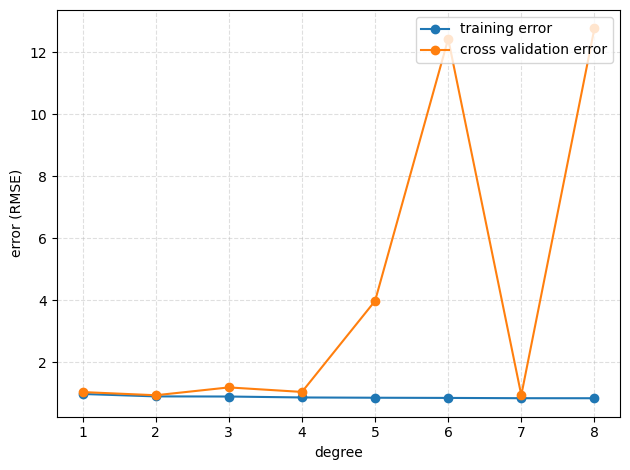

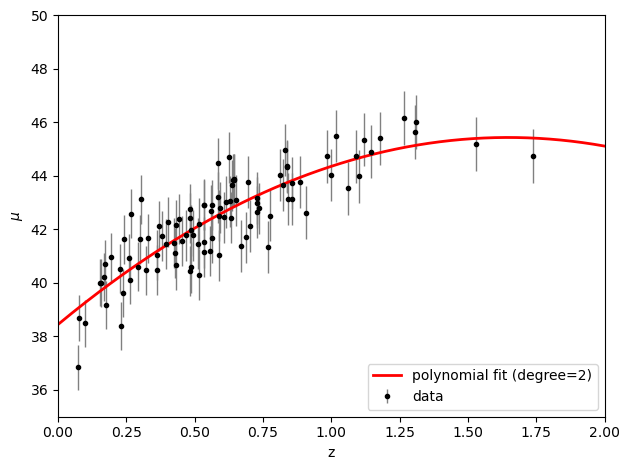

In [ ]:
# Polynomial regression

from astroML.linear_model import PolynomialRegression

d = np.arange(1, 9)
training_err = np.zeros(d.shape)
crossval_err = np.zeros(d.shape)

for i, degree in enumerate(d):
    model = PolynomialRegression(degree=degree)
    model.fit(z_sample[:, np.newaxis], mu_sample)
    tr_err, cv_err = cross_validation(z_sample, mu_sample, model)

    training_err[i] = tr_err
    crossval_err[i] = cv_err

    print(
        "Degree: {}, Training error: {:.4f}, Cross validation error: {:.4f}".format(
            degree, tr_err, cv_err
        )
    )

plt.plot(d, training_err, "-o", label="training error")
plt.plot(d, crossval_err, "-o", label="cross validation error")
plt.xlabel("degree")
plt.ylabel("error (RMSE)")
plt.xticks(d)
plt.grid(alpha=0.4, linestyle="--")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Pick the best degree from cross-validation and show the final polynomial fit.

best_idx = np.argmin(crossval_err)
best_degree = d[best_idx]

best_model = PolynomialRegression(degree=best_degree)
best_model.fit(z_sample[:, np.newaxis], mu_sample)

z_fit = np.linspace(0, 2, 200)
mu_fit = best_model.predict(z_fit[:, np.newaxis])

plt.errorbar(z_sample, mu_sample, dmu, fmt=".k", ecolor="gray", lw=1, label="data")
plt.plot(z_fit, mu_fit, "-r", lw=2, label=f"polynomial fit (degree={best_degree})")
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()